<a href="https://colab.research.google.com/github/Jhoniisjelly/Data201_JhonathanUrquilla/blob/main/Project_1_JUrquilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Violations Analysis in Montgomery County

Jhonathan Urquilla  
DATA 201 – Project 1  
4/3/2026

## Introduction

This project uses the Montgomery County Traffic Violations dataset obtained from Data.gov. The dataset contains records of traffic citations issued by law enforcement, including information such as violation type, time of stop, location, and driver characteristics. The population of interest consists of drivers who have received traffic violations in Montgomery County.

The data is collected through police enforcement, which introduces potential bias since not all violations are equally observed or recorded. Enforcement levels may vary by location and time, which can influence the results. Additionally, missing or incomplete data may affect analysis. Ethical concerns include potential bias in enforcement patterns and the interpretation of results without assuming causation.

In [31]:
# Load the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# Load Montgomery County Traffic Violations dataset
df_violations = pd.read_csv("/content/drive/MyDrive/Traffic_Violations.csv", encoding="latin1")

# Filter to Maryland only
df_violations = df_violations[df_violations['State'] == 'MD']

df_violations.head()

,SeqID,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,...,Charge,Article,Contributed To Accident,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation
0,52282e8c-f2e1-4bb5-8509-2d5e4f8da8ca,05/01/2023,23:11:00,MCP,"3rd District, Silver Spring",OPERATING UNREGISTERED MOTOR VEHICLE ON HIGHWAY,BRIGGS CHANEY RD @ COLUMIBA PIKE,0.000000,0.00000,No,...,13-401(b1),Transportation Article,False,WHITE,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(0.0, 0.0)"
1,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVING TO DRIVE MOTOR VEHICLE ON HIGHWAY WITH...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,16-101(a1),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
2,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO DISPLAY REGISTRATION CARD UPON DEMA...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,13-409(b),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
3,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVER OF MOTOR VEHICLE FOLLOWING VEHICLE CLOS...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,21-310(a),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
4,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO CONTROL VEH. SPEED ON HWY. TO AVOID...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,21-801(b),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"


In [34]:
df_violations.shape
df_violations.columns
df_violations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1820697 entries, 0 to 2096254
Data columns (total 43 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   SeqID                    object 
 1   Date Of Stop             object 
 2   Time Of Stop             object 
 3   Agency                   object 
 4   SubAgency                object 
 5   Description              object 
 6   Location                 object 
 7   Latitude                 float64
 8   Longitude                float64
 9   Accident                 object 
 10  Belts                    object 
 11  Personal Injury          object 
 12  Property Damage          object 
 13  Fatal                    object 
 14  Commercial License       object 
 15  HAZMAT                   object 
 16  Commercial Vehicle       object 
 17  Alcohol                  object 
 18  Work Zone                object 
 19  Search Conducted         object 
 20  Search Disposition       object 
 21  Search Outcom

## Quantitative Analysis

**Question:**  
What is the distribution of violations across hours of the day?

In [35]:
# Drop missing location values
df_violations = df_violations.dropna(subset=['Latitude', 'Longitude'])

# Convert date column
df_violations['Date Of Stop'] = pd.to_datetime(df_violations['Date Of Stop'], errors='coerce')

# Create new time variables
df_violations['Year'] = df_violations['Date Of Stop'].dt.year
df_violations['Month'] = df_violations['Date Of Stop'].dt.month

# Extract hour
df_violations['Hour'] = df_violations['Time Of Stop'].str[:2].astype(int)

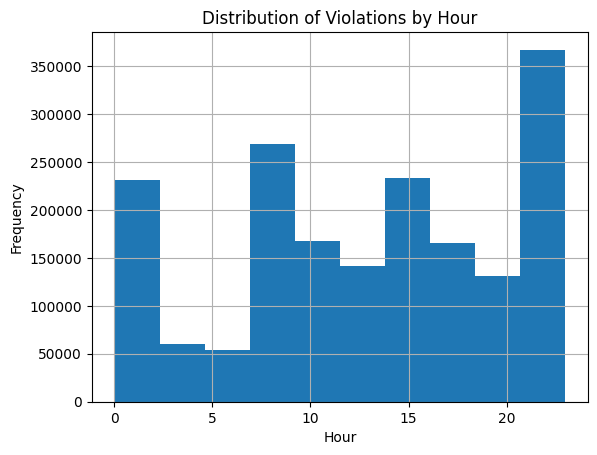

In [36]:
df_violations['Hour'].describe()

plt.figure()
df_violations['Hour'].hist()
plt.title("Distribution of Violations by Hour")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()

## Categorical Analysis

**Question:**  
What are the most common traffic violations?

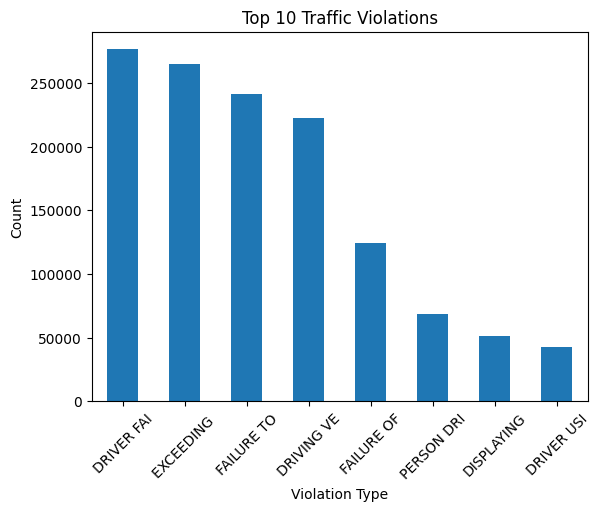

In [37]:
# Clean and shorten categories (optional but helps a lot)
df_violations['Violation_Short'] = df_violations['Description'].str[:10]

# Get top 8 only (less clutter)
top_violations = df_violations['Violation_Short'].value_counts().head(8)

top_violations

plt.figure()
top_violations.plot(kind='bar')
plt.title("Top 10 Traffic Violations")
plt.xlabel("Violation Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The most common violations include speeding and failure to obey traffic laws. The categories were simplified to improve readability. These results highlight the most frequent types of unsafe driving behavior.

## Exploratory Analysis

**Question:**  
Is there a relationship between time of day and violation type?

In [40]:
top5 = df_violations['Description'].value_counts().head(5).index
filtered = df_violations[df_violations['Description'].isin(top5)]

pd.crosstab(filtered['Hour'], filtered['Description'])

Description,DISPLAYING,DRIVER FAI,DRIVING VE,FAILURE OF,FAILURE TO
Hour,,,,,
0,1394,6812,2709,2848,3775
1,784,6377,1482,2097,2712
2,510,4571,1103,1637,1933
3,271,2662,602,1030,1210
4,162,1513,320,581,720
5,194,1088,267,408,647
6,700,2666,658,883,1335
7,1698,11373,1732,1909,3294
8,2514,16124,2702,2411,4515


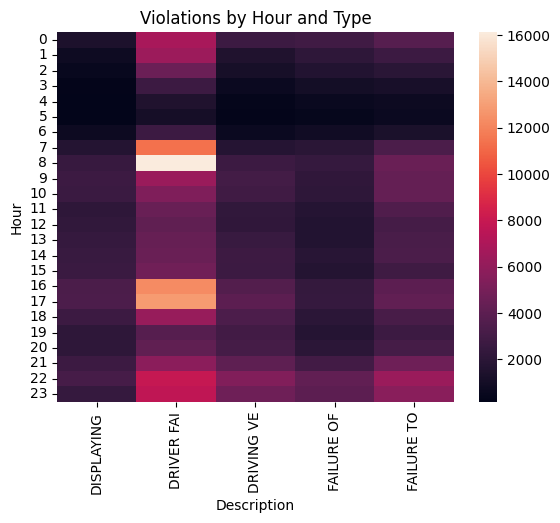

In [41]:
pivot = pd.crosstab(filtered['Hour'], filtered['Description'].str[:10])

plt.figure()
sns.heatmap(pivot)
plt.title("Violations by Hour and Type")
plt.show()

The analysis suggests the top 5 violation occur mostly all round 3am-5am with some having larger ranges of occurance. This indicates a relationship between time and type of violation, likely influenced by traffic patterns and enforcement activity.

## Nonparametric Inference

A random sample of 10% of the data was used to estimate the median hour of violations.


In [42]:
sample = df_violations.sample(frac=0.1, random_state=1)

median_hour = sample['Hour'].median()
median_hour

13.0

The median hour represents the typical time when violations occur. This method is resistant to extreme values and provides a reliable measure of central tendency.

## Conclusion

The analysis shows that traffic violations are concentrated during certain times of the day and that specific violations occur more frequently than others. These patterns suggest variations in driving behavior and enforcement activity.

Future analysis could include geographic mapping or comparison with crash data to better understand traffic safety risks and help identify locations that may require more attention for safety renovations.